# Immucan IF — Cohort FACTM (real data)

Real-data notebook in the same style as `w_loading_tests.ipynb` and
`covid_cohort_tests.ipynb`. There is no ground-truth `W` / `Z`; we use the
same **Hungarian alignment** and cohort-prior diagnostics as on COVID.

Data are loaded only from `IF*_file_df_MOFA.txt` manifests (subset filters) —
**not** by scanning all of `tables/`.

| # | Cel | W_prior | Z_prior | Co testuje |
|---|-----|---------|---------|------------|
| **RD1** | Ładowanie danych + sanity | — | — | Plan ładowania, wymiary, kohorty |
| **RD2** | Efekty kohortowe w priorze Z | ARD_SS | COHORT | `E[gamma]`, `E[gamma·delta]` per typ nowotworu |
| **RD3** | Struktura odległości kohort | ARD_SS | COHORT | Macierz odległości L2 między pozycjami kohort w latent space |
| **RD4** | Stabilność `W`: cohort vs baseline | ARD_SS | COHORT vs STD_NORMAL | `|corr(W_cohort, W_baseline)|` po Hungarian na `Z` (jak SC4 / COVID Exp 6) |
| **RD5** | Jakość dopasowania | ARD_SS | oba | ELBO, MSE rekonstrukcji, scatter `Z` |

Każda sekcja RD*: **Cel** → **Dane (given)** → **Kroki** → **Wyjścia** → **Interpretacja**.

Wymaga podmontowanego T7: `IMMUCAN_ROOT`.

### Importy

In [1]:
import os, sys, time, warnings
sys.path.insert(0, os.path.abspath('..'))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import linear_sum_assignment

from src import FACTModel
from src.cohort_data import long_df_summary
from src.enums import Likelihood, WPrior, ZPrior
from src.model_config import CohortPriorConfig, ModelConfig, SimpleViewConfig
from src.views import Views

import importlib
import immucan_data.loader as _immucan_loader
importlib.reload(_immucan_loader)
import immucan_data
importlib.reload(immucan_data)

from immucan_data import immucan_load_plan, immucan_model_config, load_immucan

### Helpery: fitting, efekty kohortowe, Hungarian, stabilność W

In [2]:
def fit_cohort(views, K, pi=0.5, max_iter=150, seed=0, n_topics=10):
    """Cohort FACTM — simple (MOFA) + spatial CTM (L=n_topics)."""
    cfg = immucan_model_config(
        views, K, z_prior=ZPrior.COHORT, pi=pi, n_topics=n_topics
    )
    m = FACTModel(views=views, K=K, model_config=cfg, seed=seed)
    m.fit(max_iter=max_iter, pretrain=True, elbo_tres=0.0)
    return m


def fit_baseline(views, K, max_iter=150, seed=0, n_topics=10):
    """Baseline — simple + spatial CTM, ZPrior.STD_NORMAL."""
    cfg = immucan_model_config(
        views, K, z_prior=ZPrior.STD_NORMAL, n_topics=n_topics
    )
    m = FACTModel(views=views, K=K, model_config=cfg, seed=seed)
    m.fit(max_iter=max_iter, pretrain=True, elbo_tres=0.0)
    return m


def extract_cohort_effects(model, K):
    """E[gamma], E[delta] per kohorta (wiersze = sorted cohort labels w priorze)."""
    priors = model.fa.node_z.z_priors
    E_g = np.column_stack([priors[k].E_gamma for k in range(K)])
    E_d = np.column_stack([priors[k].E_delta for k in range(K)])
    cohort_names = np.array([str(c) for c in priors[0].cohort.labels])
    return {
        'E_gamma': E_g,
        'E_delta': E_d,
        'cohorts': cohort_names,
        'elbo': float(model.elbo_sequence[-1]),
    }


def plot_cohort_effects(out, K, title_prefix):
    fig, axes = plt.subplots(1, 2, figsize=(11, 0.55 * len(out['cohorts']) + 2))
    sns.heatmap(out['E_gamma'] * out['E_delta'], annot=True, fmt='.2f',
                cmap='coolwarm', center=0,
                xticklabels=[f'Z{k}' for k in range(K)],
                yticklabels=out['cohorts'], ax=axes[0])
    axes[0].set_title(f'{title_prefix} — E[gamma·delta]')
    sns.heatmap(out['E_gamma'], annot=True, fmt='.2f',
                cmap='Blues', vmin=0, vmax=1,
                xticklabels=[f'Z{k}' for k in range(K)],
                yticklabels=out['cohorts'], ax=axes[1])
    axes[1].set_title(f'{title_prefix} — E[gamma]')
    plt.tight_layout()
    plt.show()


def cohort_dist(M):
    """Pairwise L2 between rows of M (pozycje kohort w latent space)."""
    diffs = M[:, None, :] - M[None, :, :]
    return np.sqrt(np.sum(diffs ** 2, axis=-1))


from src.factor_alignment import hungarian_factor_alignment as hungarian, w_stability_between_models as w_stability

---
## RD1 — Ładowanie danych Immucan IF

**Cel:** Załadować kontrolowany podzbiór próbek IF i zweryfikować wymiary przed fittingiem.

### Dane wejściowe (given)
- `IMMUCAN_ROOT` — katalog `05_IF_table_extraction` na T7
- `IMMUCAN_PANELS` — np. `("IF1",)` lub `("IF1","IF2","IF3")` (przecięcie próbek)
- `FIRST_N_PER_COHORT` — pierwsze N próbek per kohorta w kolejności manifestu (np. 8)
- **Simple:** agregacja per TSV (proporcje `celltype`, `tissue`, markery; tumor ROI)
- **Structured:** okna kNN (75 komórek) z `tables/` → CTM, `L=10` topików
- Z-score per widok (`standardize=True` w `load_immucan`)

### Co robimy (steps)
1. `immucan_load_plan(...)` — ile plików TSV zostanie odczytanych (bez skanowania `tables/`).
2. `load_immucan(...)` — budowa `Views` + etykiety kohort (`BC1`, `NSCLC`, …).
3. Print `long_df_summary` i wymiary macierzy.

### Co dostajemy (outputs)
- Słownik planu ładowania + `N`, liczba widoków, rozkład kohort.

### Interpretacja
- `n_tsv_files_to_read` powinno być << liczby plików w `tables/` (~2600+).

In [3]:
IMMUCAN_ROOT = "/Volumes/T7/immucan/results/IF/05_IF_table_extraction"
IMMUCAN_PANELS = ("IF1",)
IMMUCAN_COHORTS = None
IMMUCAN_SAMPLE_IDS = None
FIRST_N_PER_COHORT = 8  # first rows per cohort in manifest (not random)
REBUILD_CACHE = False

K = 6
MAX_ITER = 150
PI = 0.5
SEED = 0

print(immucan_load_plan(
    IMMUCAN_ROOT,
    panels=IMMUCAN_PANELS,
    cohorts=IMMUCAN_COHORTS,
    sample_ids=IMMUCAN_SAMPLE_IDS,
    first_n_per_cohort=FIRST_N_PER_COHORT,
))

data = load_immucan(
    IMMUCAN_ROOT,
    panels=IMMUCAN_PANELS,
    cohorts=IMMUCAN_COHORTS,
    sample_ids=IMMUCAN_SAMPLE_IDS,
    first_n_per_cohort=FIRST_N_PER_COHORT,
    max_samples_per_cohort=None,
    rebuild_cache=REBUILD_CACHE,
    standardize=True,
    progress=True,
)
views = data.views
cohort_labels = data.cohorts
print(long_df_summary(data.long_df))
print(f"N={views.N}  simple_views={views.num_simple}  K={K}")
for i, sv in enumerate(views.simple):
    print(f"  view {i}: shape {sv.data.shape}")

{'panels': ['IF1'], 'n_tsv_files_to_read': 40, 'per_panel': {'IF1': {'n_samples': 40, 'cohorts': {'IMMU_BC1': 8, 'IMMU_NSCLC': 8, 'IMMU_RCC': 8, 'IMMU_SCCHN1': 8, 'SYNG_BC1': 8}}}, 'structured_views': 'one CTM view per panel (spatial kNN windows from tables/)', 'default_topics': 10, 'default_window_size': 75, 'note': 'Manifest paths only; does not scan tables/ beyond listed TSVs.'}
Immucan: reading 40 TSV files (manifest only, not scanning tables/). Per panel: {'IF1': 40}


panels: 100%|██████████| 1/1 [00:43<00:00, 43.69s/it]


Immucan: cached to data/immucan_IF1_cc39202ad7bb.csv


structured panels: 100%|██████████| 1/1 [00:41<00:00, 41.50s/it]

Immucan: structured cache saved to data/immucan_structured_IF1_8b179c73cd62.pkl
{'n_rows': 454, 'n_samples': 27, 'n_views': 1, 'views': ['IF1'], 'n_features': 17, 'cohorts': {'BC1': 6, 'NSCLC': 5, 'RCC': 4, 'SCCHN1': 6, 'SYG_BC1': 6}}
N=27  simple_views=1  K=6
  view 0: shape (27, 17)


---
## RD2 — Efekty kohortowe (`E[gamma]`, `E[gamma·delta]`)

**Cel:** Sprawdzić, czy prior kohortowy przypisuje czynniki do typów nowotworu (jak COVID Exp 1–3).

### Dane wejściowe (given)
- `views` z RD1, `K` czynników, `fit_cohort` z `pi=0.5`

### Co robimy (steps)
1. Dopasuj `model_cohort = fit_cohort(views, K)`.
2. `extract_cohort_effects` → heatmapy `E[gamma·delta]` i `E[gamma]`.

### Co dostajemy (outputs)
- Dwie heatmapy kohorta × czynnik.
- Ostatni ELBO.

### Interpretacja
- Wiersze o wysokim `E[gamma]` dla wybranych `Z_k` sugerują czynniki „kohortowe”.
- Brak wyraźnej struktury nie oznacza błędu — sygnał biologiczny może być słaby przy małym `N`.

Pretraining CTM for structured view 0
Pretraining FA
Fitting model


100%|██████████| 150/150 [00:20<00:00,  7.44it/s]


Cohort fit [s]: 20.8  ELBO=-1203301.28


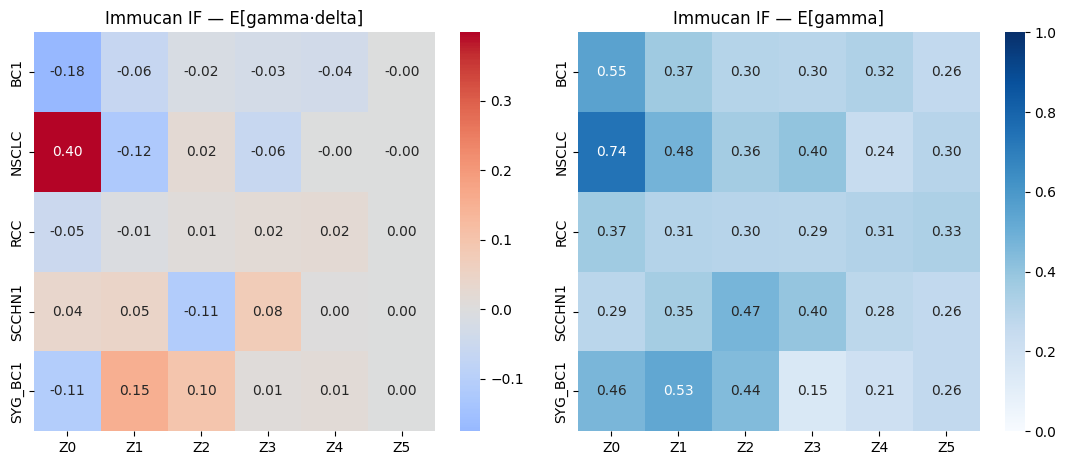

In [4]:
t0 = time.time()
model_cohort = fit_cohort(views, K, pi=PI, max_iter=MAX_ITER, seed=SEED)
print(f"Cohort fit [s]: {time.time() - t0:.1f}  ELBO={model_cohort.elbo_sequence[-1]:.2f}")

cohort_out = extract_cohort_effects(model_cohort, K)
plot_cohort_effects(cohort_out, K, title_prefix='Immucan IF')

---
## RD3 — Odległości między kohortami w latent space

**Cel:** Zobaczyć geometryczną separację kohort po pozycjach `E[gamma·delta]` (COVID Exp 4).

### Co robimy (steps)
1. `M = E_gamma * E_delta` (macierz C × K).
2. `cohort_dist(M)` → heatmapa odległości L2.

### Co dostajemy (outputs)
- Heatmapa C × C z odległościami między kohortami.

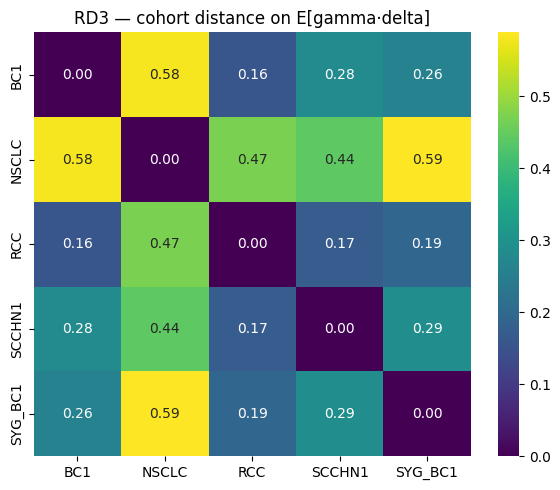

In [5]:
M = cohort_out['E_gamma'] * cohort_out['E_delta']
D = cohort_dist(M)
plt.figure(figsize=(6, 5))
sns.heatmap(D, annot=True, fmt='.2f', cmap='viridis',
            xticklabels=cohort_out['cohorts'],
            yticklabels=cohort_out['cohorts'])
plt.title('RD3 — cohort distance on E[gamma·delta]')
plt.tight_layout()
plt.show()

---
## RD4 — Stabilność ładunków W: cohort vs baseline (jak SC4 / COVID Exp 6)

**Cel:** Sprawdzić, czy prior kohortowy nie psuje przestrzeni cech `W` względem modelu bez kohort.

### Dane wejściowe (given)
- Ten sam `views`, `K`, `seed`
- `model_cohort` (RD2) + nowy `model_baseline = fit_baseline(...)`

### Co robimy (steps)
1. Dopasuj baseline (`ZPrior.STD_NORMAL`).
2. `w_stability(model_cohort, model_baseline, K)` — Hungarian na `Z`, potem `|corr(W)|` per czynnik per widok.
3. Wykres słupkowy średnich `|corr|` per widok; próg `0.75` jak w SC1.

### Co dostajemy (outputs)
- Tablica `|corr|` per factor; wykres z progiem 0.75.

### Interpretacja
- Wysokie `|corr|` (np. > 0.75) → kohortowy prior zostawia te same osie cech co baseline.
- Niskie wartości na wybranych czynnikach → prior przesuwa interpretację ładunków.

Pretraining CTM for structured view 0
Pretraining FA
Fitting model


100%|██████████| 150/150 [00:20<00:00,  7.45it/s]

Baseline fit [s]: 20.8  ELBO=-1203275.51
View 0  mean|corr(W)| = 0.831  per-factor: [0.998 0.996 0.998 0.996 0.998 0.   ]
View 1  mean|corr(W)| = 0.831  per-factor: [0.997 0.995 0.999 0.996 0.999 0.   ]


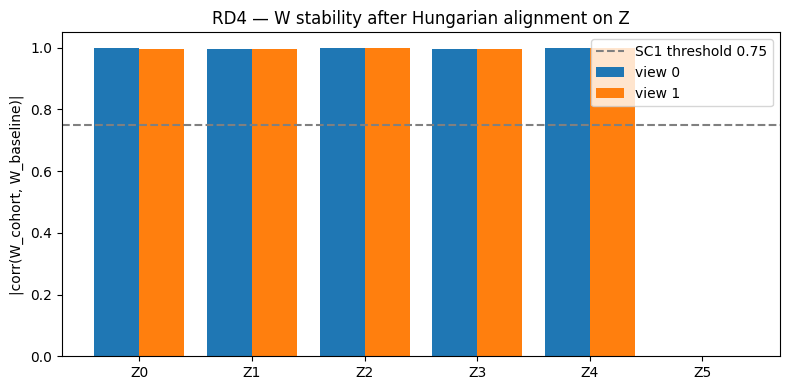

In [6]:
t1 = time.time()
model_baseline = fit_baseline(views, K, max_iter=MAX_ITER, seed=SEED)
print(f"Baseline fit [s]: {time.time() - t1:.1f}  ELBO={model_baseline.elbo_sequence[-1]:.2f}")

w_corrs, perm, signs = w_stability(model_cohort, model_baseline, K)
for v, corrs in enumerate(w_corrs):
    print(f"View {v}  mean|corr(W)| = {corrs.mean():.3f}  per-factor: {np.round(corrs, 3)}")

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(K)
width = 0.8 / max(1, len(w_corrs))
for v, corrs in enumerate(w_corrs):
    ax.bar(x + v * width, corrs, width=width, label=f'view {v}')
ax.axhline(0.75, color='gray', ls='--', label='SC1 threshold 0.75')
ax.set_xticks(x + width * (len(w_corrs) - 1) / 2)
ax.set_xticklabels([f'Z{k}' for k in range(K)])
ax.set_ylabel('|corr(W_cohort, W_baseline)|')
ax.set_title('RD4 — W stability after Hungarian alignment on Z')
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()

---
## RD5 — ELBO, rekonstrukcja, latent scatter

**Cel:** Porównać jakość dopasowania baseline vs cohort (jak końcówka `run_cohort` + SC1-style MSE).

### Co robimy (steps)
1. Wykres ELBO w czasie.
2. MSE widoku 0 (dane z-score).
3. Scatter pierwszych dwóch czynników `Z` z modelu kohortowego, kolor = typ nowotworu.

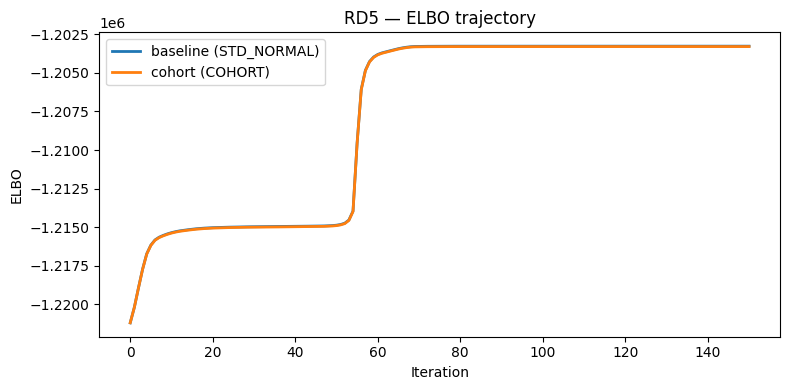

View0 MSE baseline: 0.207
View0 MSE cohort:   0.207


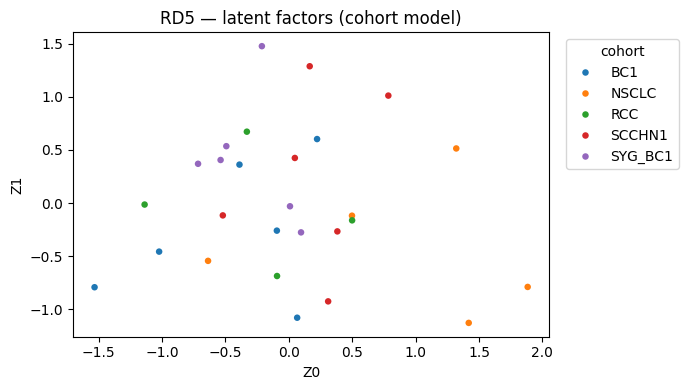

In [7]:
elbo_b = np.asarray(model_baseline.elbo_sequence, dtype=float)
elbo_c = np.asarray(model_cohort.elbo_sequence, dtype=float)

plt.figure(figsize=(8, 4))
plt.plot(elbo_b, label='baseline (STD_NORMAL)', linewidth=2)
plt.plot(elbo_c, label='cohort (COHORT)', linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('ELBO')
plt.title('RD5 — ELBO trajectory')
plt.legend()
plt.tight_layout()
plt.show()

if views.num_simple > 0:
    y0 = views.simple[0].data
    mse_b = float(np.nanmean((y0 - model_baseline.get_predictions_FA(0)) ** 2))
    mse_c = float(np.nanmean((y0 - model_cohort.get_predictions_FA(0)) ** 2))
    print('View0 MSE baseline:', round(mse_b, 4))
    print('View0 MSE cohort:  ', round(mse_c, 4))

z = model_cohort.get_latent_factors()
if z.shape[1] >= 2:
    df_plot = pd.DataFrame({'Z0': z[:, 0], 'Z1': z[:, 1], 'cohort': cohort_labels})
    plt.figure(figsize=(7, 4))
    sns.scatterplot(data=df_plot, x='Z0', y='Z1', hue='cohort', palette='tab10', s=22, linewidth=0)
    plt.title('RD5 — latent factors (cohort model)')
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='cohort')
    plt.tight_layout()
    plt.show()